# Understanding Data Types and Choosing the Right Chart

In this notebook we will learn:

• What different **types of data** are  
• Why data types matter for visualization  
• How to choose the **right chart** for the question you want to answer  

This notebook focuses on **thinking about data**, not just building charts.


To learn these things, we'll be working with a dataset from Kaggle that explores the connection between sleep quality and health. It can be found here: https://www.kaggle.com/datasets/mohankrishnathalla/sleep-health-and-daily-performance-dataset

In [1]:
# First, let's import the libraries we'll need for our notebook exercises and graphs:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from quiz_answers import get_answer

In [2]:
# Now let's load the data into a Pandas DataFrame and take a look at the first five rows
df = pd.read_csv("sleep_health_dataset.csv")
df.head()

,person_id,age,gender,occupation,bmi,country,sleep_duration_hrs,sleep_quality_score,rem_percentage,deep_sleep_percentage,...,heart_rate_resting_bpm,sleep_aid_used,shift_work,room_temperature_celsius,weekend_sleep_diff_hrs,season,day_type,cognitive_performance_score,sleep_disorder_risk,felt_rested
0,1,29,Female,Driver,25.7,Japan,6.19,6.6,22.5,19.3,...,63,0,0,20.1,1.84,Autumn,Weekday,73.4,Healthy,0
1,2,55,Female,Software Engineer,22.0,USA,8.32,6.9,26.9,14.9,...,52,1,0,18.0,0.13,Winter,Weekend,99.4,Healthy,1
2,3,42,Male,Nurse,25.0,India,3.74,1.0,20.2,16.2,...,72,0,1,17.9,1.67,Spring,Weekend,2.5,Severe,0
3,4,37,Female,Student,29.5,India,6.79,6.4,17.7,17.7,...,71,0,0,19.1,2.37,Summer,Weekend,67.8,Healthy,0
4,5,23,Male,Lawyer,23.6,Spain,5.02,3.2,23.3,18.3,...,71,0,0,19.7,1.26,Summer,Weekday,38.1,Mild,0


# Understanding Data Types

Before choosing a chart, we must first understand the **type of data** we are working with.  
The type of data determines which visualizations will communicate information most clearly.

At the highest level, data falls into **two main categories**:

```
|---Categorical
    |---Nominal
    |---Ordinal
|---Numerical
    |--- Discrete
    |--- Continuous
```
---

# Categorical Data

Categorical data represents **labels, groups, or categories** rather than numeric measurements.

Examples from this dataset:
- `gender`
- `occupation`
- `country`
- `chronotype`
- `sleep_disorder_risk`

Categorical data can be divided into **two subtypes**.

### Nominal Data

Nominal data represents categories that **do not have a natural order**.

Examples:
- Gender: Male, Female  
- Occupation: Engineer, Teacher, Nurse  
- Country: USA, Canada, UK  
- Chronotype: Morning, Evening  

There is **no ranking or ordering** between these categories.

You cannot say:
- Morning > Evening  
- USA < Canada  

These are simply **different labels**.

Nominal data is commonly visualized using:
- Bar charts
- Count plots


### Ordinal Data

Ordinal data represents categories that **do have a meaningful order or ranking**.

Examples from this dataset:

- `sleep_disorder_risk` (e.g., Low < Medium < High)
- `sleep_quality_score` (when interpreted as a rating scale)

The categories have a **logical progression**, but the **distance between them is not necessarily equal**.

For example, the difference between a sleep score of 6 and 7 may not represent the same change as between 8 and 9.

Ordinal data is often visualized using:
- Bar charts
- Box plots (when treated numerically)

---

# Numerical Data

Numerical data represents **quantitative values** that can be measured or counted.

Examples from this dataset:
- `sleep_duration_hrs`
- `bmi`
- `steps_that_day`
- `heart_rate_resting_bpm`

Numerical data can be divided into **two subtypes**.


### Discrete Data

Discrete data represents **countable numbers**, usually whole numbers.

Examples:
- `wake_episodes_per_night`
- `steps_that_day`
- `nap_duration_mins`
- `heart_rate_resting_bpm`

These values typically **cannot be fractional** in a meaningful way.

For example:
- You can wake up **3 times** during the night, but not **3.7 times**

Discrete data is commonly visualized using:
- Bar charts
- Histograms


### Continuous Data

Continuous data represents **measured values that can take any value within a range**.

Examples:
- `sleep_duration_hrs`
- `bmi`
- `rem_percentage`
- `room_temperature_celsius`
- `stress_score`

These values can include **decimals or fractions**.

Examples:
- 6.5 hours of sleep  
- BMI of 24.7  
- 18.3°C  

Continuous data is commonly visualized using:
- Histograms
- Line charts
- Scatter plots
- Box plots

---

# Connecting This to Our Dataset

Now that we understand the different types of data, we can apply this framework directly to our dataset.

In the next section, we will break down each column and identify:
- Its data type
- How it should be interpreted
- How it might be visualized effectively

In [3]:
# Use info method to learn about the column names, data types, and number of non-null observations in this dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 32 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   person_id                    100000 non-null  int64  
 1   age                          100000 non-null  int64  
 2   gender                       100000 non-null  object 
 3   occupation                   100000 non-null  object 
 4   bmi                          100000 non-null  float64
 5   country                      100000 non-null  object 
 6   sleep_duration_hrs           100000 non-null  float64
 7   sleep_quality_score          100000 non-null  float64
 8   rem_percentage               100000 non-null  float64
 9   deep_sleep_percentage        100000 non-null  float64
 10  sleep_latency_mins           100000 non-null  int64  
 11  wake_episodes_per_night      100000 non-null  int64  
 12  caffeine_mg_before_bed       100000 non-null  int64  
 13  

# Dataset Overview: Sleep Health and Lifestyle Dataset

This dataset contains 100,000 observations of individuals and their sleep patterns, behaviors, and health-related factors. It includes a rich mix of categorical, ordinal, discrete, and continuous numerical data, making it ideal for practicing data exploration, visualization, and modeling.

## Column Breakdown

- **person_id**  
  *Type:* Categorical (Nominal / Identifier, stored as int)  
  A unique identifier for each individual. Not meaningful for analysis beyond distinguishing records.

- **age**  
  *Type:* Numerical (Discrete)  
  Age in years. While numeric, it is recorded as whole numbers.

- **gender**  
  *Type:* Categorical (Nominal)  
  Gender of the individual (e.g., Male, Female).

- **occupation**  
  *Type:* Categorical (Nominal)  
  Job or profession of the individual.

- **bmi**  
  *Type:* Numerical (Continuous)  
  Body Mass Index, a continuous health measurement.

- **country**  
  *Type:* Categorical (Nominal)  
  Country of residence.

- **sleep_duration_hrs**  
  *Type:* Numerical (Continuous)  
  Total hours slept.

- **sleep_quality_score**  
  *Type:* Numerical (Continuous, often treated as Ordinal)  
  A score representing sleep quality. Although numeric, it represents a ranked scale.

- **rem_percentage**  
  *Type:* Numerical (Continuous)  
  Percentage of sleep spent in REM stage.

- **deep_sleep_percentage**  
  *Type:* Numerical (Continuous)  
  Percentage of sleep spent in deep sleep.

- **sleep_latency_mins**  
  *Type:* Numerical (Discrete)  
  Time (in minutes) it takes to fall asleep.

- **wake_episodes_per_night**  
  *Type:* Numerical (Discrete)  
  Number of times the individual wakes during the night.

- **caffeine_mg_before_bed**  
  *Type:* Numerical (Discrete)  
  Amount of caffeine consumed before bed (in mg).

- **alcohol_units_before_bed**  
  *Type:* Numerical (Continuous)  
  Alcohol consumption before bed.

- **screen_time_before_bed_mins**  
  *Type:* Numerical (Discrete)  
  Minutes of screen time before sleep.

- **exercise_day**  
  *Type:* Numerical (Binary / Discrete)  
  Indicates whether the individual exercised that day (likely 0 = No, 1 = Yes).

- **steps_that_day**  
  *Type:* Numerical (Discrete)  
  Total steps taken.

- **nap_duration_mins**  
  *Type:* Numerical (Discrete)  
  Length of naps in minutes.

- **stress_score**  
  *Type:* Numerical (Continuous, often treated as Ordinal)  
  A stress rating scale.

- **work_hours_that_day**  
  *Type:* Numerical (Continuous)  
  Total hours worked.

- **chronotype**  
  *Type:* Categorical (Nominal)  
  Sleep preference (e.g., morning person, night owl).

- **mental_health_condition**  
  *Type:* Categorical (Nominal)  
  Reported mental health condition.

- **heart_rate_resting_bpm**  
  *Type:* Numerical (Discrete)  
  Resting heart rate in beats per minute.

- **sleep_aid_used**  
  *Type:* Numerical (Binary / Discrete)  
  Indicates whether sleep aids were used (0/1).

- **shift_work**  
  *Type:* Numerical (Binary / Discrete)  
  Indicates whether the individual works shifts.

- **room_temperature_celsius**  
  *Type:* Numerical (Continuous)  
  Room temperature during sleep.

- **weekend_sleep_diff_hrs**  
  *Type:* Numerical (Continuous)  
  Difference in sleep duration between weekdays and weekends.

- **season**  
  *Type:* Categorical (Nominal)  
  Season during which data was recorded.

- **day_type**  
  *Type:* Categorical (Nominal)  
  Indicates weekday vs weekend.

- **cognitive_performance_score**  
  *Type:* Numerical (Continuous)  
  A performance metric, likely derived from cognitive tests.

- **sleep_disorder_risk**  
  *Type:* Categorical (Nominal)  
  Risk category for sleep disorders.

- **felt_rested**  
  *Type:* Numerical (Binary / Discrete)  
  Indicates whether the individual felt rested (0/1).

## Summary

This dataset includes:

- **Categorical (Nominal):** gender, occupation, country, chronotype, mental_health_condition, season, day_type, sleep_disorder_risk  
- **Categorical (Binary):** exercise_day, sleep_aid_used, shift_work, felt_rested  
- **Numerical (Discrete):** age, sleep_latency_mins, wake_episodes_per_night, steps_that_day, nap_duration_mins, heart_rate_resting_bpm  
- **Numerical (Continuous):** bmi, sleep_duration_hrs, rem_percentage, deep_sleep_percentage, alcohol_units_before_bed, stress_score, work_hours_that_day, room_temperature_celsius, weekend_sleep_diff_hrs, cognitive_performance_score  
- **Hybrid (Continuous but often treated as Ordinal):** sleep_quality_score, stress_score  

This variety makes the dataset ideal for:
- Comparing groups (bar charts)
- Analyzing trends (line charts)
- Exploring relationships (scatter plots)
- Understanding distributions (histograms, box plots)
- Practicing real-world data interpretation

## 1. Bar Chart

A **bar chart** is a good choice when we want to compare values across categories.

Here, we use a bar chart to compare the **average sleep duration** for each **sleep disorder risk level**.  
This works well because:

- `sleep_disorder_risk` is **categorical (ordinal)**
- `sleep_duration_hrs` is **numerical**
- we want to compare one measured value across groups

This kind of chart makes it easy to see how sleep duration changes across different risk levels and identify any clear trends or patterns.

<Axes: xlabel='sleep_disorder_risk'>

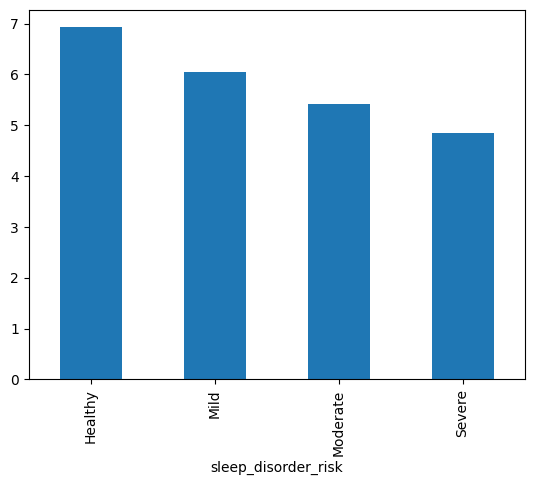

In [4]:
avg_sleep = df.groupby("sleep_disorder_risk")["sleep_duration_hrs"].mean()

avg_sleep.plot(kind="bar")

## 2. Line Chart

A **line chart** is a good choice when we want to show how a value changes across an **ordered sequence**.

This is most commonly used for **time-based data**, but it can also be used with any variable that has a **natural order or progression**.

A line chart works best when:
- the x-axis represents a **continuous or ordered variable** (such as time, age, or a numeric scale)
- the data points follow a **logical sequence**
- we want to highlight **trends, patterns, or direction of change**

Line charts are especially useful for identifying:
- upward or downward trends  
- cycles or patterns  
- points where values increase or decrease  

Here, we use a line chart to show the **average sleep duration** across different **ages**.  
This works well because:

- `age` is **numerical and ordered**
- `sleep_duration_hrs` is **numerical**
- we want to observe how sleep duration changes as age increases

This kind of chart makes it easy to see overall trends, even if individual values fluctuate slightly.

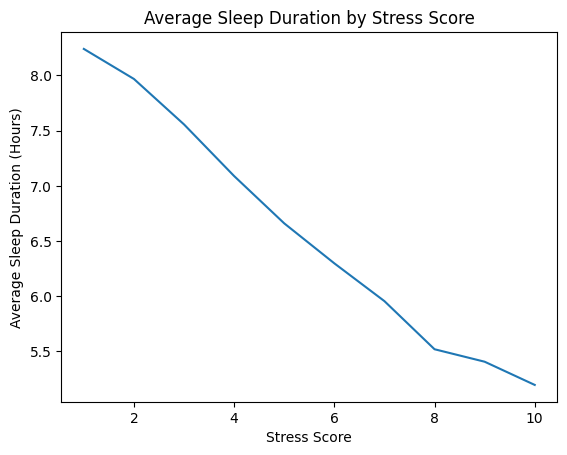

In [5]:
# round stress score to make grouping cleaner
df["stress_group"] = df["stress_score"].round()

avg_sleep_by_stress = df.groupby("stress_group")["sleep_duration_hrs"].mean()

plt.plot(avg_sleep_by_stress.index, avg_sleep_by_stress.values)
plt.title("Average Sleep Duration by Stress Score")
plt.xlabel("Stress Score")
plt.ylabel("Average Sleep Duration (Hours)")
plt.show()

## 3. Scatter Plot

A **scatter plot** is a good choice when we want to explore the **relationship between two numerical variables**.

This type of chart allows us to see how one variable changes in relation to another and helps identify patterns such as trends, clusters, or correlations.

Scatter plots work best when:
- both variables are **numerical**
- we want to understand whether a relationship exists between them
- we are looking for patterns rather than exact values

Here, we use a scatter plot to compare **sleep quality** and **cognitive performance**.  
This works well because:

- `sleep_quality_score` is **numerical**
- `cognitive_performance_score` is **numerical**
- we want to explore whether better sleep quality is associated with improved performance

This kind of chart makes it easy to see whether a relationship exists and whether it appears to be positive, negative, or unclear.

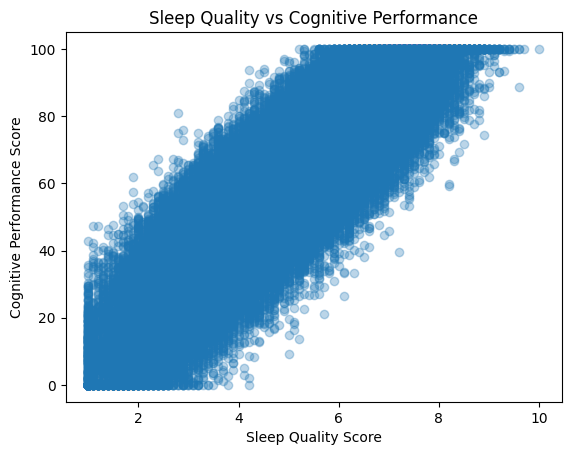

In [6]:
plt.scatter(df["sleep_quality_score"], df["cognitive_performance_score"], alpha=0.3)
plt.title("Sleep Quality vs Cognitive Performance")
plt.xlabel("Sleep Quality Score")
plt.ylabel("Cognitive Performance Score")
plt.show()

## 4. Pie Chart

A **pie chart** is a good choice when we want to show how a whole is divided into parts.

It is most useful when:
- we have a **small number of categories**
- we want to show **proportions or percentages**
- all categories together represent a **complete whole**

Here, we use a pie chart to show the distribution of individuals across different **sleep disorder risk levels**.  
This works well because:

- `sleep_disorder_risk` is **categorical**
- each category represents a portion of the dataset
- we want to understand how the population is divided across these groups

This kind of chart makes it easy to see which categories make up larger or smaller portions of the whole.

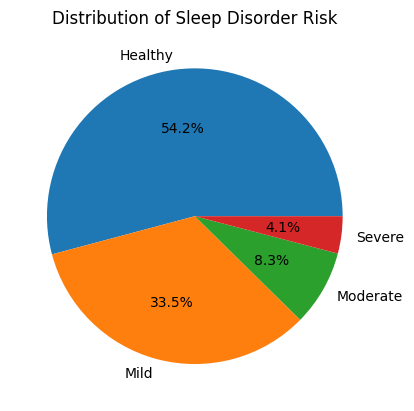

In [7]:
risk_counts = df["sleep_disorder_risk"].value_counts()

plt.pie(risk_counts, labels=risk_counts.index, autopct="%1.1f%%")
plt.title("Distribution of Sleep Disorder Risk")
plt.show()

## 5. Box Plot

A **box plot** is a good choice when we want to compare the **distribution of a numerical variable across categories**.

Unlike a bar chart, which shows only an average, a box plot shows:
- the median  
- the spread of the data  
- possible outliers  

This makes it useful for understanding how values vary within each group.

Here, we use a box plot to compare **sleep duration** across different **day types**.  
This works well because:

- `day_type` is **categorical**
- `sleep_duration_hrs` is **numerical**
- we want to compare how the distribution of sleep differs between groups

This kind of chart makes it easy to see differences in typical values, variability, and outliers between categories.

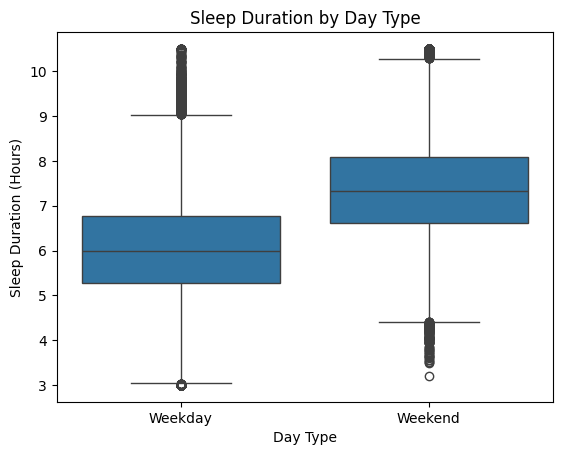

In [8]:
sns.boxplot(data=df, x="day_type", y="sleep_duration_hrs")
plt.title("Sleep Duration by Day Type")
plt.xlabel("Day Type")
plt.ylabel("Sleep Duration (Hours)")
plt.show()

## 6. Histogram

A **histogram** is a good choice when we want to understand the **distribution of a single numerical variable**.

It groups values into ranges (bins) and shows how many observations fall into each range.

Histograms are useful for identifying:
- the overall shape of the data  
- where values are concentrated  
- whether the data is symmetric or skewed  

Here, we use a histogram to examine the distribution of **sleep latency** (how long it takes to fall asleep).  
This works well because:

- `sleep_latency_mins` is **numerical**
- we want to understand how these values are distributed across the dataset
- this variable is likely to show variation and possible skew

This kind of chart makes it easy to see whether most people fall asleep quickly or if there is a wider spread of values.

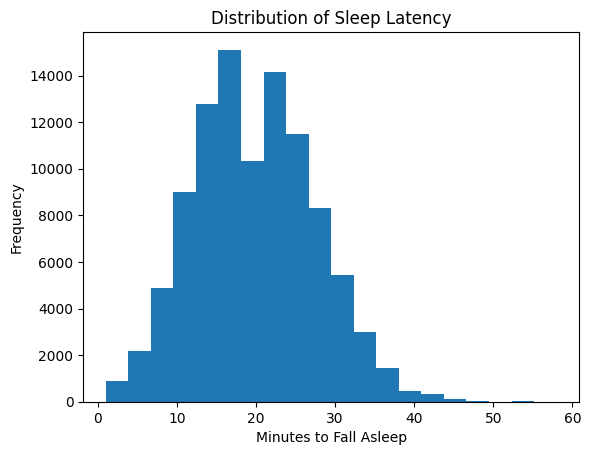

In [9]:
plt.hist(df["sleep_latency_mins"], bins=20)
plt.title("Distribution of Sleep Latency")
plt.xlabel("Minutes to Fall Asleep")
plt.ylabel("Frequency")
plt.show()

## 7. Heatmap

A **heatmap** is a good choice when we want to examine **relationships between multiple numerical variables at once**.

It is commonly used to visualize a **correlation matrix**, where each value represents how strongly two variables are related.

Heatmaps are useful for:
- identifying strong or weak relationships  
- spotting patterns across many variables  
- quickly comparing multiple pairs of variables  

Here, we use a heatmap to visualize correlations between several **sleep, stress, and performance variables**.  
This works well because:

- all selected columns are **numerical**
- these variables are expected to be related in meaningful ways
- a heatmap allows us to compare many relationships at once

This kind of chart makes it easy to identify which variables tend to increase together, decrease together, or show little relationship.

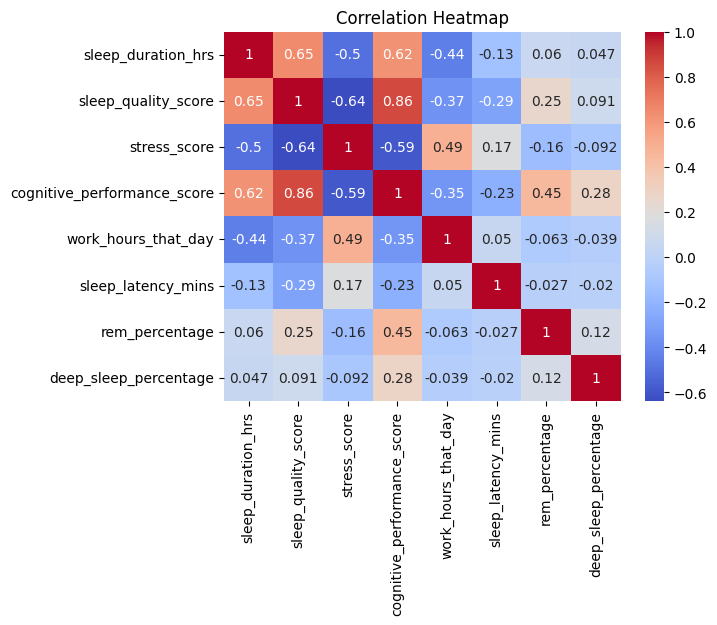

In [10]:
corr_cols = [
    "sleep_duration_hrs",
    "sleep_quality_score",
    "stress_score",
    "cognitive_performance_score",
    "work_hours_that_day",
    "sleep_latency_mins",
    "rem_percentage",
    "deep_sleep_percentage"
]

corr_matrix = df[corr_cols].corr()

sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

## 8. Diverging Bar Chart

A **diverging bar chart** is a variation of a bar chart that shows how values compare relative to a central reference point, such as an average.

Values extend:
- to the right if they are **above the reference point**
- to the left if they are **below the reference point**

This type of chart is useful when:
- we want to compare differences from a baseline  
- we want to clearly highlight above vs below average values  

Here, we compare **average sleep duration by occupation**, centered around the overall average sleep duration.  
This works well because:

- `occupation` is **categorical**
- `sleep_duration_hrs` is **numerical**
- we want to see which groups sleep more or less than average

This kind of chart makes it easy to quickly identify which categories fall above or below the overall average.

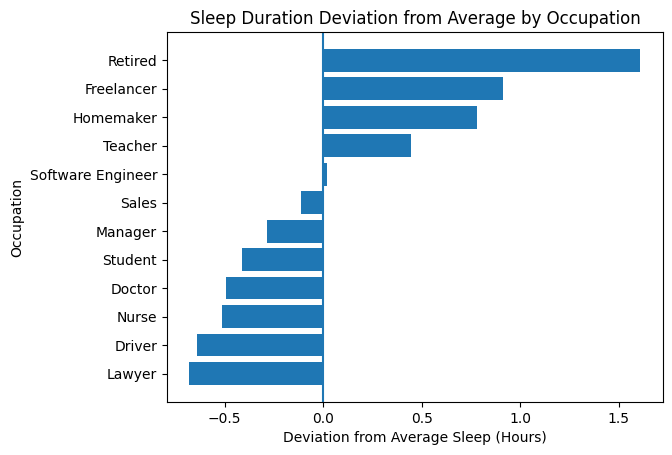

In [11]:
# average sleep by occupation
avg_sleep = df.groupby("occupation")["sleep_duration_hrs"].mean()

# overall average
overall_avg = df["sleep_duration_hrs"].mean()

# deviation from average
deviation = avg_sleep - overall_avg

# sort for cleaner display
deviation = deviation.sort_values()

plt.barh(deviation.index, deviation.values)
plt.axvline(0)  # center line

plt.title("Sleep Duration Deviation from Average by Occupation")
plt.xlabel("Deviation from Average Sleep (Hours)")
plt.ylabel("Occupation")
plt.show()

## 9. Hexbin Plot

A **hexbin plot** is a good choice when a scatter plot becomes too dense and points overlap.

Instead of plotting every individual point, a hexbin plot groups points into hexagonal bins and shows how many observations fall into each area.

This is useful when:
- we have a **large dataset**
- a scatter plot appears as a **blob of points**
- we want to understand the **density of relationships**

Here, we use a hexbin plot to compare **work hours** and **cognitive performance**.  
This works well because:

- both variables are **numerical**
- the dataset contains many observations
- a standard scatter plot would be difficult to interpret

This kind of chart makes it easier to see where data points are concentrated and whether patterns exist.

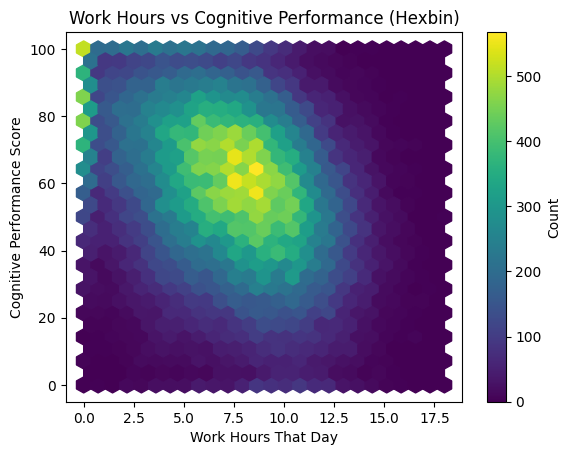

In [12]:
plt.hexbin(
    df["work_hours_that_day"],
    df["cognitive_performance_score"],
    gridsize=25
)
plt.colorbar(label="Count")
plt.title("Work Hours vs Cognitive Performance (Hexbin)")
plt.xlabel("Work Hours That Day")
plt.ylabel("Cognitive Performance Score")
plt.show()

## 10. Bubble Chart

A **bubble chart** is useful when we want to explore the relationship between **three variables at once**.

It extends a scatter plot by using the size of each point to represent a third variable.

This type of chart is most effective when:
- all variables are meaningful to the same question  
- the third variable adds useful context  
- we want to explore how multiple factors interact  

Here, we explore the question:

**How do sleep and physical activity relate to cognitive performance?**

We use:
- `sleep_duration_hrs` on the x-axis  
- `cognitive_performance_score` on the y-axis  
- `steps_that_day` to represent activity level (bubble size)  

This works well because:

- all three variables are **numerical**
- they represent related aspects of health and behavior  
- the bubble size adds context to the relationship between sleep and performance  

This kind of chart helps reveal whether more active individuals tend to follow different patterns in sleep and performance.

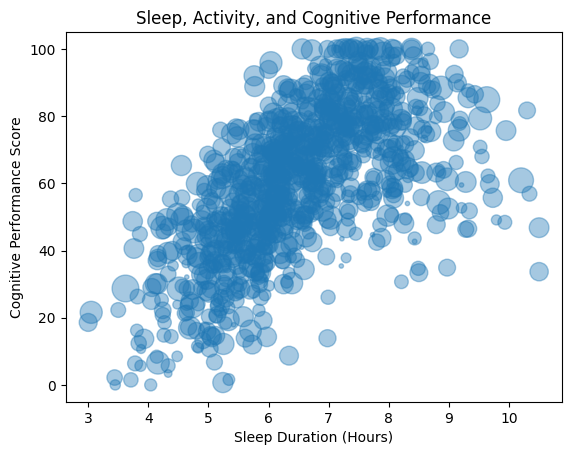

In [13]:
sample_df = df.sample(1000)

plt.scatter(
    sample_df["sleep_duration_hrs"],
    sample_df["cognitive_performance_score"],
    s=sample_df["steps_that_day"] / 50,
    alpha=0.4
)

plt.title("Sleep, Activity, and Cognitive Performance")
plt.xlabel("Sleep Duration (Hours)")
plt.ylabel("Cognitive Performance Score")
plt.show()

## 11. Correlation Pair Grid

A **pair grid** (or pair plot) is a powerful tool for exploring relationships between multiple numerical variables at once.

It creates:
- scatter plots for each pair of variables  
- distributions along the diagonal  

This is useful when:
- we want to explore multiple relationships simultaneously  
- we are in an **exploratory data analysis (EDA)** phase  
- we want to quickly identify patterns or correlations  

Here, we use a pair grid to examine relationships between several **sleep, stress, and performance variables**.  
This works well because:

- all selected variables are **numerical**
- we want to compare multiple relationships at once
- this chart provides both relationships and distributions in a single view

This kind of chart helps identify which variables may be related and which are not.

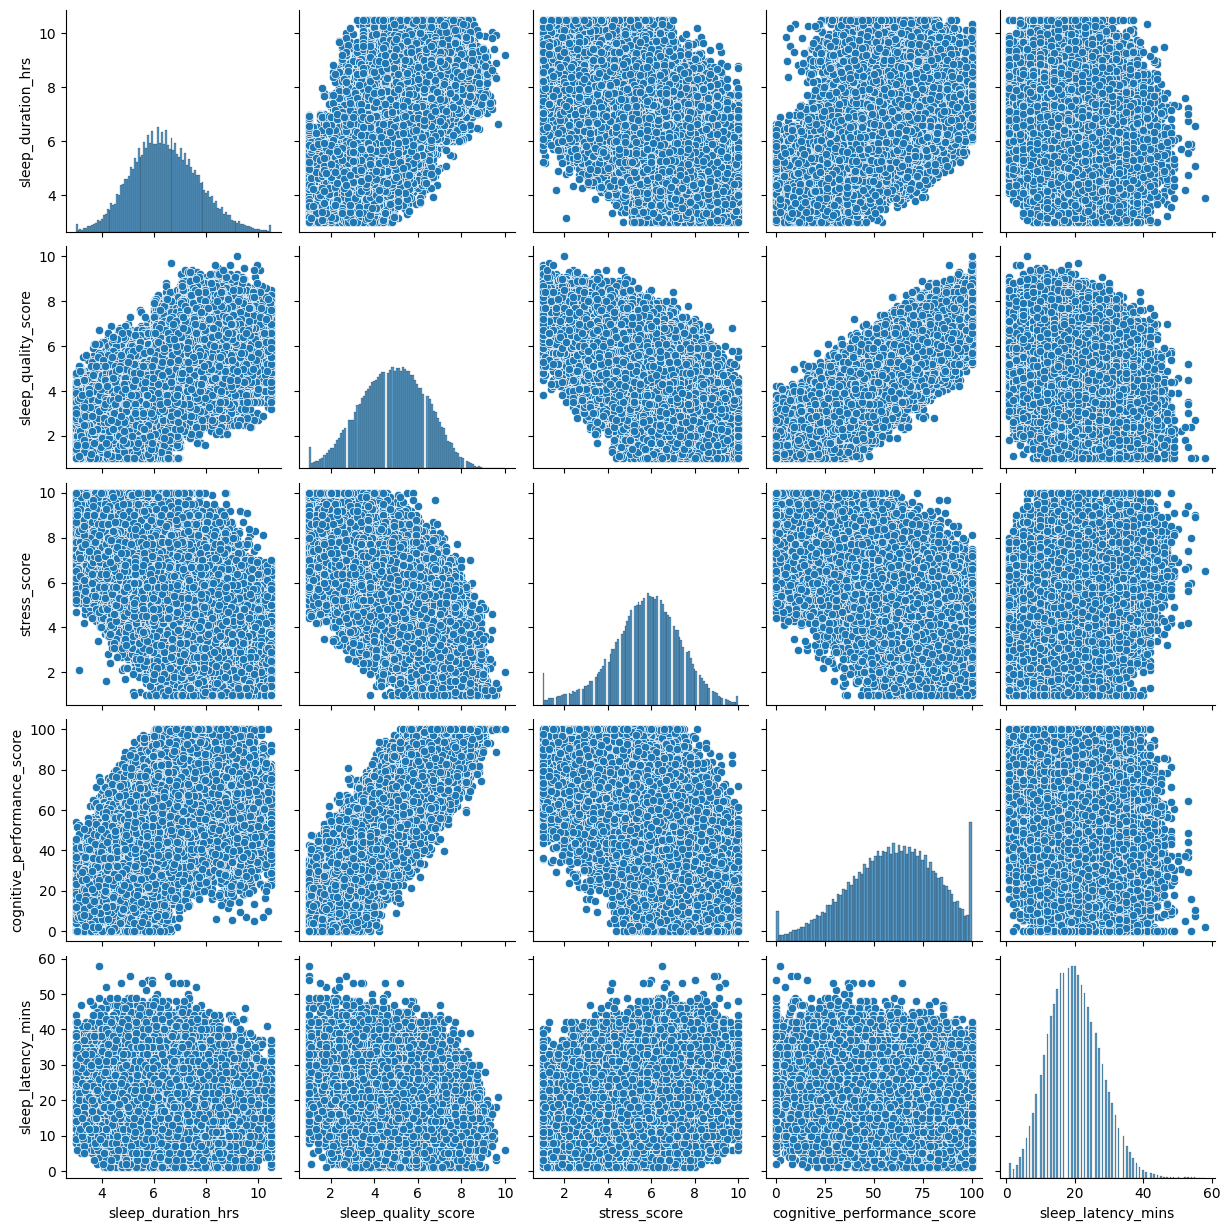

In [14]:
pair_cols = [
    "sleep_duration_hrs",
    "sleep_quality_score",
    "stress_score",
    "cognitive_performance_score",
    "sleep_latency_mins"
]

sns.pairplot(df[pair_cols])
plt.show()

# Knowledge Check

Test your understanding of data types and chart selection.  
Choose the best answer for each question.

---

### 1. Which of the following is an example of **numerical continuous data**?

A. Number of customers  
B. Temperature in degrees  
C. Product category  
D. Customer ID  

---

### 2. Which of the following is an example of **categorical ordinal data**?

A. Colors (red, blue, green)  
B. Customer ID numbers  
C. Satisfaction rating (1–5 stars)  
D. Height in inches  

---

### 3. Which chart is BEST for showing the **distribution of a single numerical variable**?

A. Bar chart  
B. Histogram  
C. Pie chart  
D. Scatter plot  

---

### 4. Which chart is BEST for comparing values across **categories**?

A. Line chart  
B. Scatter plot  
C. Bar chart  
D. Heatmap  

---

### 5. When should you use a **line chart**?

A. When comparing categories  
B. When showing proportions of a whole  
C. When exploring relationships between variables  
D. When showing change across an ordered sequence or time  

---

### 6. When should you use a **scatter plot**?

A. When showing the distribution of one variable  
B. When comparing categories  
C. When exploring the relationship between two numerical variables  
D. When showing proportions  

---

### 7. Which situation is BEST suited for a **bubble chart**?

A. Comparing the counts of categories  
B. Showing how a single variable is distributed  
C. Exploring the relationship between two variables only  
D. Exploring the relationship between three variables at once  

---

## Check Your Answers

Run the cell below, then enter the question number to see the correct answer.

Example:
- Enter `1` to check Question 1

In [15]:
from quiz_answers import get_answer

while True:
    user_input = input("Enter question number (1-7) or 'q' to quit: ")
    
    if user_input.lower() == 'q':
        break
    
    if user_input.isdigit():
        get_answer(int(user_input))
    else:
        print("Please enter a valid number.")